In [1]:
import joblib
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import duckdb

# 1. Load the model and data
pipeline = joblib.load('../data/processed/biocascade_model.joblib')
con = duckdb.connect('../data/processed/biocascade.db')
df_full = con.execute("SELECT * FROM feature_matrix_raw").df()

# 2. Re-create the test set 
features = ['age', 'diastolic_bp', 'log_triglycerides']
X = df_full[features]
y = df_full['is_high_risk']
_, X_test, _, _ = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Detect the model step automatically (Fixes the KeyError)
# This looks for the last step in your pipeline
model_step_name = pipeline.steps[-1][0]
model = pipeline.named_steps[model_step_name]

print(f"✅ Found model step: '{model_step_name}'")

# 4. Initialize SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("🔍 BioCascade Interpretability Engine: ONLINE")

/home/wtc/Desktop/BioCascade/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Found model step: 'rf'
🔍 BioCascade Interpretability Engine: ONLINE


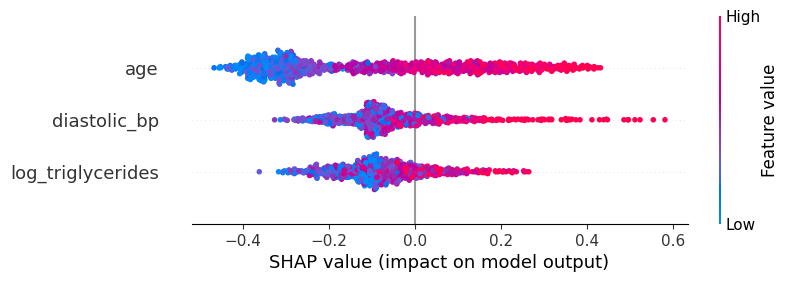

In [4]:
import numpy as np
import shap

# 1. Extract the SHAP values from the explainer we built in Cell 1
# We use the 'shap_values' variable created in Cell 1
if isinstance(shap_values, list):
    # If it's a list (typical for Random Forest), index 1 is 'High Risk'
    s_vals = shap_values[1]
else:
    s_vals = shap_values

# 2. Prepare the data matrix for display
X_display = X_test.values

# 3. Handle 3D arrays (some SHAP versions return [samples, features, classes])
if len(s_vals.shape) > 2:
    final_s_vals = s_vals[:, :, 1]
else:
    final_s_vals = s_vals

# 4. Create the final Explanation object
explanation = shap.Explanation(
    values=final_s_vals, 
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value, 
    data=X_display, 
    feature_names=features
)

# 5. Render the Beeswarm Plot
shap.plots.beeswarm(explanation)

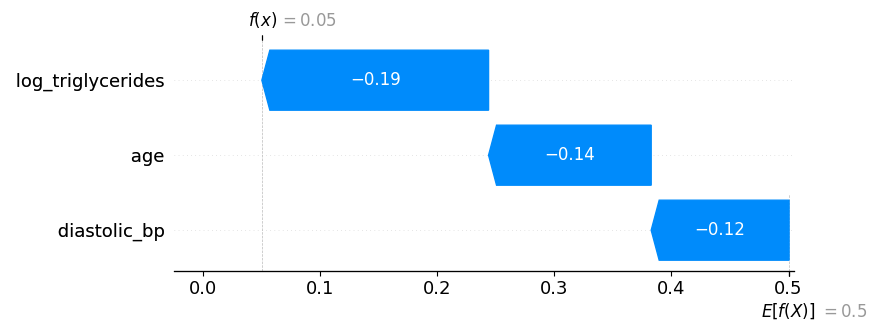

In [ ]:

shap.plots._waterfall.waterfall_legacy(
    explanation.base_values[0] if hasattr(explanation.base_values, "__len__") else explanation.base_values, 
    explanation.values[0], 
    explanation.data[0],
    feature_names=features
)